## O Dataset "Wine"

Para nosso exercício de **Simbolistas vs. Analogistas**, utilizaremos o clássico dataset de Vinhos (*Wine Recognition Dataset*). Ele contém resultados de uma análise química de vinhos cultivados na mesma região da Itália, mas derivados de três cultivos (cultivars) diferentes.

### O Objetivo (Target / Y)
Nossa variável alvo é a **Classe do Vinho**. Queremos que o algoritmo descubra, baseando-se apenas na química, de qual uva o vinho veio.
* **0, 1, 2:** Representam os três tipos de uvas.

### As Características (Features / X)
O dataset possui 13 colunas no total. Abaixo, detalhamos as que aparecem na nossa amostra e que causam o "conflito matemático":

1.  Álcool (`alcohol`): O teor alcoólico percentual.
  

2.  Fenóis não-flavanoides (`nonflavanoid_phenols`): Compostos químicos que afetam o sabor amargo e a oxidação do vinho.

3.  Magnésio (`magnesium`): Mineral natural presente no solo e na uva.


4. Intensidade da Cor (`color_intensity`): O quão escuro/intenso é o vinho visualmente.

5.  Prolina (`proline`): Um aminoácido abundante em vinhos maduros. É o "vilão" deste exemplo.
    * *Efeito:* Como os números são grandes comparadados com os demais, qualquer pequena variação percentual na Prolina gera uma "distância" numérica de centenas de pontos. Isso ofusca todas as outras colunas.

---


Vamos usar **todas** as colunas para treinar os modelos, mas preste atenção no duelo:

> **Prolina (1000+)  vs.  Fenóis (0.2)**

* Para os **Simbolistas (Árvore)**: Não importa. A árvore vai perguntar "A Prolina é > 700?" e depois "Os Fenóis são > 0.3?". A distancia entre os pontos não implica no descoberta das regras.
* Para os **Analogistas (KNN)**: A Prolina é grande, os Fenóis pequenos em numero. A distância Euclidiana (pitagoras) será dominada pela Prolina, fazendo o algoritmo "ignorar" a química sutil dos Fenóis se não fizermos o escalonamento.

=== Variação de Escala (Média das Colunas) ===
           proline  nonflavanoid_phenols
count   178.000000            178.000000
mean    746.893258              0.361854
std     314.907474              0.124453
min     278.000000              0.130000
25%     500.500000              0.270000
50%     673.500000              0.340000
75%     985.000000              0.437500
max    1680.000000              0.660000

Nota: A 'Proline' é ~2000x maior que os 'Fenóis'. Isso distorce a geometria.



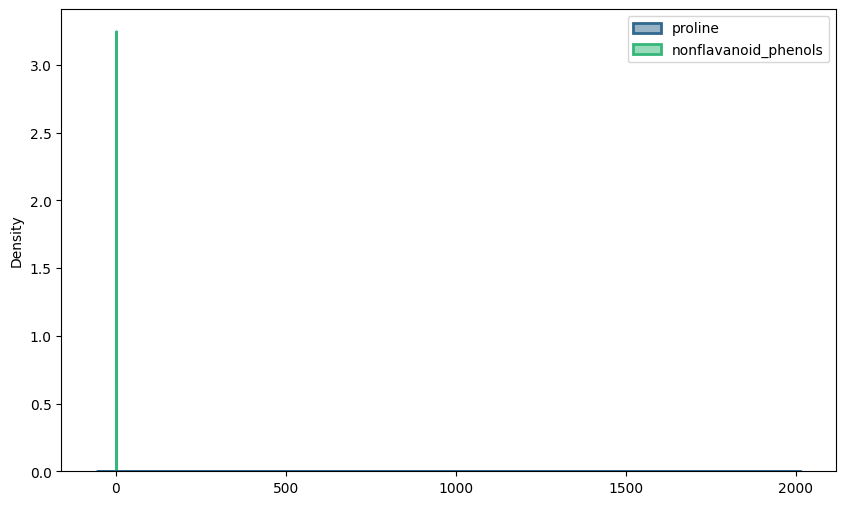

------------------------------
CENÁRIO A: Dados Originais (Brutos)
------------------------------
Tribo Simbolista (Árvore) Acurácia: 90.74%
Tribo Analogista (KNN)    Acurácia: 77.78%
>> Observe como o KNN sofre aqui.

------------------------------
CENÁRIO B: Dados Escalonados (StandardScaler)
------------------------------
Tribo Simbolista (Árvore) Acurácia: 90.74%
Tribo Analogista (KNN)    Acurácia: 98.15%

=== RESUMO FINAL ===
Mudança na Árvore: 0.00% (Indiferente à escala)
Mudança no KNN:    +20.37% (Salvo pelo pré-processamento!)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier # Tribo Simbolista
from sklearn.neighbors import KNeighborsClassifier # Tribo Analogista
from sklearn.metrics import accuracy_score

# Carregando os dados (Dataset 'Wine')
data = load_wine()
X = data.data
y = data.target

# Mostrando a discrepância de escalas

df_exemplo = pd.DataFrame(X, columns=data.feature_names)
print("=== Variação de Escala (Média das Colunas) ===")
print(df_exemplo[['proline', 'nonflavanoid_phenols']].describe())
print("\nNota: A 'Proline' é ~2000x maior que os 'Fenóis'. Isso distorce a geometria.\n")

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_exemplo[['proline', 'nonflavanoid_phenols']],
    fill=True,         # Preenche a área sob a curva (ótimo para comparações visuais)
    common_norm=False, # Importante: Calcula a normalização para cada variável independentemente
    alpha=0.5,         # Transparência (0.0 a 1.0) para enxergar a interseção
    linewidth=2,
    palette="viridis"
)
plt.show()

# Divisão Treino e Teste (Seed fixa para reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

# CENÁRIO A: DADOS ORIGINAIS (SEM ESCALA)
print("-" * 30)
print("CENÁRIO A: Dados Originais (Brutos)")
print("-" * 30)

# Simbolista (Árvore)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

# Analogista (KNN)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
acc_knn = accuracy_score(y_test, knn.predict(X_test))

print(f"Tribo Simbolista (Árvore) Acurácia: {acc_tree:.2%}")
print(f"Tribo Analogista (KNN)    Acurácia: {acc_knn:.2%}")
print(">> Observe como o KNN sofre aqui.")

# CENÁRIO B: DADOS ESCALONADOS (PRÉ-PROCESSAMENTO)
print("\n" + "-" * 30)
print("CENÁRIO B: Dados Escalonados (StandardScaler)")
print("-" * 30)

# Aplicando a padronização (Z-score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simbolista (Árvore) - Re-treinando com dados escalados
tree.fit(X_train_scaled, y_train)
acc_tree_scaled = accuracy_score(y_test, tree.predict(X_test_scaled))

# Analogista (KNN) - Re-treinando com dados escalados
knn.fit(X_train_scaled, y_train)
acc_knn_scaled = accuracy_score(y_test, knn.predict(X_test_scaled))

print(f"Tribo Simbolista (Árvore) Acurácia: {acc_tree_scaled:.2%}")
print(f"Tribo Analogista (KNN)    Acurácia: {acc_knn_scaled:.2%}")

# CONCLUSÃO FINAL
print("\n=== RESUMO FINAL ===")
diff_tree = acc_tree_scaled - acc_tree
diff_knn = acc_knn_scaled - acc_knn

print(f"Mudança na Árvore: {diff_tree:.2%} (Indiferente à escala)")
print(f"Mudança no KNN:    +{diff_knn:.2%} (Salvo pelo pré-processamento!)")

In [ ]:
# Como ficaram os dados depois do escalonamento
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
df_scaled_full = pd.DataFrame(X_scaled_full, columns=data.feature_names)

print("\n=== APÓS ESCALONAMENTO ===")
print(df_scaled_full[['proline', 'nonflavanoid_phenols']].describe().round(3))


=== APÓS ESCALONAMENTO ===
       proline  nonflavanoid_phenols
count  178.000               178.000
mean    -0.000                -0.000
std      1.003                 1.003
min     -1.493                -1.868
25%     -0.785                -0.740
50%     -0.234                -0.176
75%      0.758                 0.610
max      2.971                 2.402


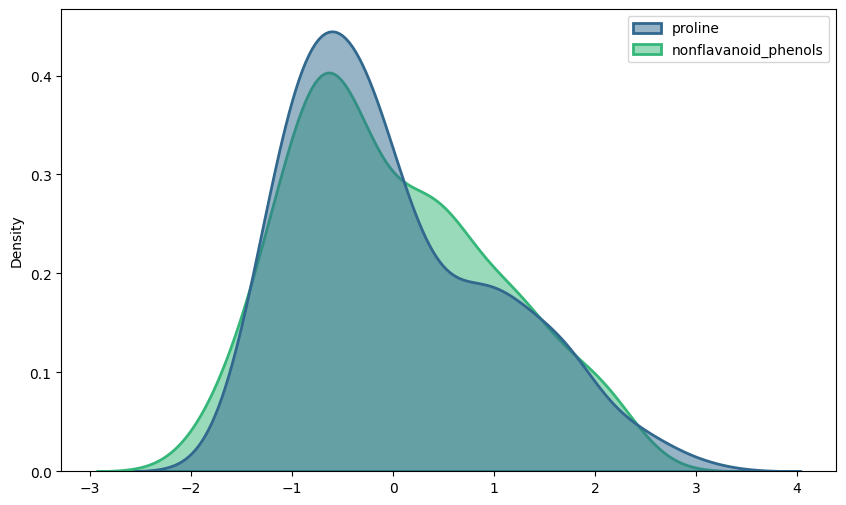

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_scaled_full[['proline', 'nonflavanoid_phenols']],
    fill=True,         # Preenche a área sob a curva (ótimo para comparações visuais)
    common_norm=False, # Importante: Calcula a normalização para cada variável independentemente
    alpha=0.5,         # Transparência (0.0 a 1.0) para enxergar a interseção
    linewidth=2,
    palette="viridis"
)
plt.show()